# Computing the predictions

It's time to see how your net performs on unseen `test` data. We will divide the tutorial in 3 parts depending on whether you want to:
* Predict filepaths contained in a [dataset split .txt file](#Predicting-a-datasplit-txt-file)
* Predict [local images](#Predicting-local-files)
* Predict [url images](#Predicting-image-urls)

**Note** Parameters in UPPERCASE letters must be changed by the user if needed.

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pylab as plt
import yaml
from tensorflow.keras.models import load_model
from planktonclas import paths, config
from planktonclas.data_utils import load_image,compute_meanRGB, load_data_splits, load_class_names ,create_data_splits,load_aphia_ids
from planktonclas.test_utils import predict
from planktonclas import paths, plot_utils, utils
# 2023-06-05_143422
# User parameters to set


TIMESTAMP = 'Phytoplankton_EfficientNetV2B0'             # timestamp of the model
MODEL_NAME = 'final_model.h5'                           # model to use to make the prediction
TOP_K = 5                                               # number of top classes predictions to save

# Set the timestamp
paths.timestamp = TIMESTAMP

# Load the data
# splits_dir="/srv/phyto-plankton-classification/data/demo-dataset_files"
class_names = load_class_names(splits_dir=paths.get_ts_splits_dir())

# Load training configuration
conf_path = os.path.join(paths.get_conf_dir(), 'conf.json')
with open(conf_path) as f:
    conf = json.load(f)
    
# Load the model
# model = load_model(os.path.join(rf"\\qarchive\data_simonstevin\zooscan\not_processed\Max\2026-02-18_151924\ckpts", MODEL_NAME), custom_objects=utils.get_custom_objects())
model = load_model(os.path.join(paths.get_checkpoints_dir(), MODEL_NAME), custom_objects=utils.get_custom_objects())

: 

# 1 Predicting a datasplit txt file

Here we are going to compute the predictions and save them into a `.json` file to retireve them later. 

## 1.0 DEMO version of your own? 

### Demo version

In [3]:
conf_path = "../etc/demo-config.yaml"
DEMO=True

### other model

In [4]:
conf_path = "../etc/config.yaml"
DEMO=False

## 1.1 Split and predict 

In [5]:
SPLIT_NAME = 'DS_split_test'                   # dataset split to predict                                      # data split to use
# conf['general']['images_directory'] = '/media/ignacio/Datos/datasets/semillas/datasets/RJB'  # custom the absolute path to the images directory, if needed


with open(conf_path, 'r') as f:
    CONF = yaml.safe_load(f)

CONF = config.get_conf_dict(CONF)


splits_dir = paths.get_splits_dir()

# #if using DEMO
if not DEMO:
    CONF['general']['images_directory']="../data/images"

if 'train.txt' not in os.listdir(splits_dir ):
    if not (CONF['dataset']['split_ratios']):
        if (CONF['training']['use_validation']) & (CONF['testing']['use_test']):
            split_ratios=[0.7,0.15,0.15]
        elif (CONF['training']['use_validation']) & (~CONF['testing']['use_test']):
            split_ratios=[0.9,0.1,0]
        else:
            split_ratios=[1,0,0]
    else:
        split_ratios=(CONF['dataset']['split_ratios'])
    create_data_splits(splits_dir=splits_dir,
                                    im_dir=CONF['general']['images_directory'],
                                    split_ratios=split_ratios)
        
        
aphia_ids = load_aphia_ids(splits_dir)


# Load the training data
X_train, y_train = load_data_splits(splits_dir=splits_dir,
                                    im_dir=CONF['general']['images_directory'],
                                    split_name='train')



X_test, y_test = load_data_splits(splits_dir=splits_dir,
                                im_dir=CONF['general']['images_directory'],
                                split_name='test')


# Compute the mean and std RGB values
if CONF["dataset"]["mean_RGB"] is None:
    CONF["dataset"]["mean_RGB"], CONF["dataset"]["std_RGB"] = compute_meanRGB(
        X_train
    )

# Predict
pred_lab, pred_prob = predict(model, X_test, conf, top_K=TOP_K, filemode='local')


if aphia_ids is not None:
    pred_aphia_ids = [aphia_ids[i] for i in pred_lab]
else:
    pred_aphia_ids= aphia_ids

class_index_map = {index:class_name for index, class_name in enumerate(class_names)}

# Convert arrays of strings to lists of integers
pred_lab = [[class_index_map[label] for label in labels] for labels in pred_lab]
y_test=[class_index_map.get(index) for index in y_test]
# Create the pred_dict as you were doing before
pred_dict = {
    'filenames': list(X_test),
    'pred_lab': pred_lab,
    'pred_prob': pred_prob.tolist(),
    'aphia_ids': pred_aphia_ids,
}
if y_test is not None:
    pred_dict['true_lab'] = y_test



pred_path = os.path.join(paths.get_predictions_dir(), '{}+{}+top{}.json'.format(MODEL_NAME, SPLIT_NAME, TOP_K))
with open(pred_path, 'w') as outfile:
    json.dump(pred_dict, outfile, sort_keys=True)


2026-03-17 10:59:38 - planktonclas.data_utils - INFO - [data] Loading aphia IDs
2026-03-17 10:59:38 - planktonclas.data_utils - INFO - [data] Loading train split
2026-03-17 10:59:38 - planktonclas.data_utils - INFO - [data] Loading test split
100%|██████████| 82/82 [00:05<00:00, 14.60it/s]
2026-03-17 10:59:43 - planktonclas.data_utils - INFO - [data] Mean RGB pixel: [142.34101527548236, 142.34101527548236, 142.34101527548236]
2026-03-17 10:59:43 - planktonclas.data_utils - INFO - [data] RGB standard deviation: [45.52169288103683, 45.52169288103683, 45.52169288103683]


⚙ GPU is NOT available. Using CPU.
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


## 2 Predicting local files

#### Predict a single local image

⚙ GPU is NOT available. Using CPU.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


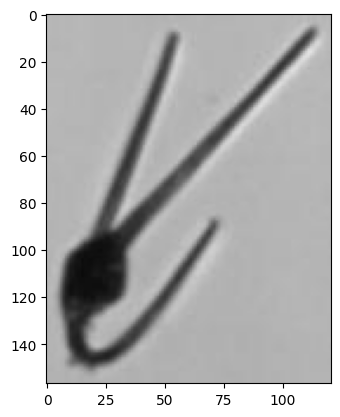

[99.5%] Tripos
[0.3%] Ceratium_horridum+C._longipes
[0.2%] Tripos_fusus
[0.0%] Zooplankton
[0.0%] Chaetoceros


In [6]:

FILEPATH = '/srv/phyto-plankton-classification/data/samples/random/Tripos_0B6AD65F-41F6-480B-AB23-2C1A02F992B1_494057.jpg'
if not os.path.isfile(FILEPATH):
    FILEPATH = '../data/samples/random/Tripos_0B6AD65F-41F6-480B-AB23-2C1A02F992B1_494057.jpg'
pred_lab, pred_prob = predict(model, FILEPATH, conf, top_K=TOP_K, filemode='local')

plt.imshow(load_image(FILEPATH, filemode='local'))
plt.show()
for j in range(pred_lab.shape[1]):
    print('[{:.1f}%] {}'.format(pred_prob[0, j] * 100, class_names[pred_lab[0, j]]))

#### Predict a list of local images

⚙ GPU is NOT available. Using CPU.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


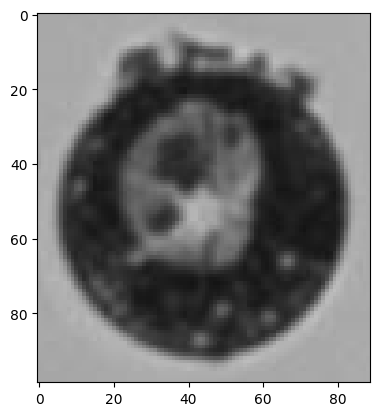

[99.8%] Actinoptychus
[0.2%] Centric_Diatom
[0.0%] Stellarima_stellaris+Podosira+Hyalodiscus
[0.0%] Eucampia
[0.0%] Actinoptychus_senarius


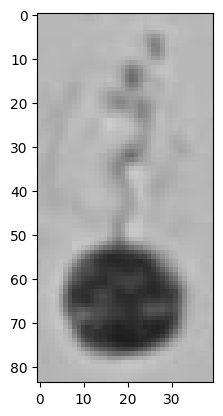

[100.0%] Peritrichia
[0.0%] Ciliophora
[0.0%] Bacillariophyceae
[0.0%] Centric_Diatom
[0.0%] Bubbles


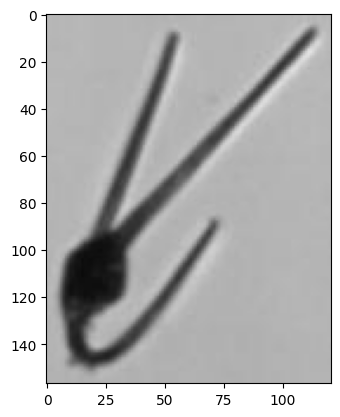

[99.5%] Tripos
[0.3%] Ceratium_horridum+C._longipes
[0.2%] Tripos_fusus
[0.0%] Zooplankton
[0.0%] Chaetoceros


In [7]:
FILEPATHS = glob.glob('/srv/phyto-plankton-classification//data/samples/random/*')
if len(FILEPATHS)==0:
    FILEPATHS = glob.glob('../data/samples/random/*')   
pred_lab, pred_prob = predict(model, FILEPATHS, conf, top_K=TOP_K, filemode='local')

for i, im_path in enumerate(FILEPATHS):
    plt.figure(i)
    plt.imshow(load_image(im_path, filemode='local'))
    plt.show()
    for j in range(pred_lab.shape[1]):
        print('[{:.1f}%] {}'.format(pred_prob[i, j] * 100, class_names[pred_lab[i, j]]))

#### Predict a list of local images belonging to the same observation

In this case all the images belong to the same observation so we wan to average the predictions among all of them.

In [8]:
FILEPATHS = glob.glob('/srv/phyto-plankton-classification/data/samples/tripos/*')
if len(FILEPATHS)==0:
    FILEPATHS = glob.glob('../data/samples/tripos/*')
pred_lab, pred_prob = predict(model, FILEPATHS, conf, top_K=TOP_K, filemode='local', merge=True)

for j in range(pred_lab.shape[1]):
    print('[{:.1f}%] {}'.format(pred_prob[0, j] * 100, class_names[pred_lab[0, j]]))

⚙ GPU is NOT available. Using CPU.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[84.0%] Tripos
[15.9%] Ceratium_horridum+C._longipes
[0.1%] Tripos_fusus
[0.0%] Detritus
[0.0%] Trieres_sinensis


## 3 Predicting image urls

#### Predict a single url

⚙ GPU is NOT available. Using CPU.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


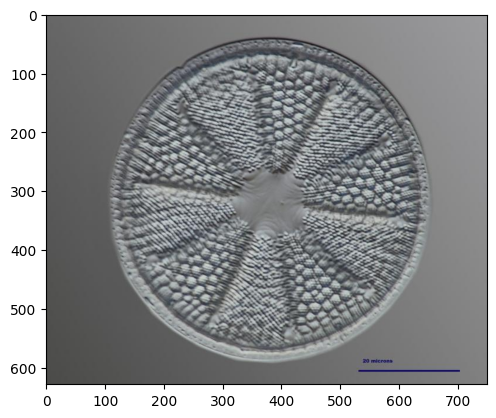

[72.4%] Centric_Diatom
[12.9%] Phytoplankton_Colony
[6.5%] Zooplankton
[4.6%] Artefact
[2.5%] Crustacea


In [9]:
FILEPATH = 'https://forum.mikroscopia.com/uploads/monthly_07_2017/post-2056-0-71322100-1501364951_thumb.jpg'

pred_lab, pred_prob = predict(model, FILEPATH, conf, top_K=TOP_K, filemode='url')

plt.imshow(load_image(FILEPATH, filemode='url'))
plt.show()
for j in range(pred_lab.shape[1]):
    print('[{:.1f}%] {}'.format(pred_prob[0, j] * 100, class_names[pred_lab[0, j]]))

#### Predict a list of urls

⚙ GPU is NOT available. Using CPU.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step


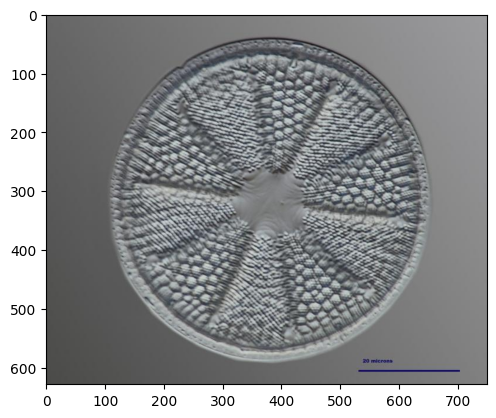

[72.4%] Centric_Diatom
[12.9%] Phytoplankton_Colony
[6.5%] Zooplankton
[4.6%] Artefact
[2.5%] Crustacea


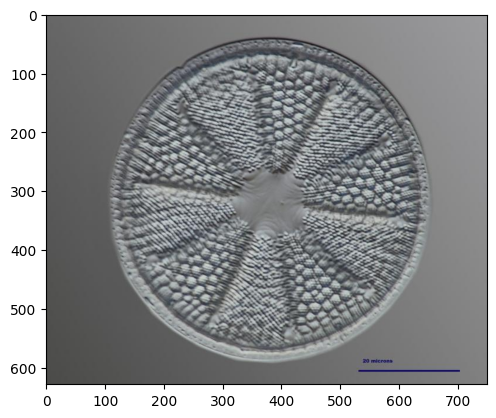

[72.4%] Centric_Diatom
[12.9%] Phytoplankton_Colony
[6.5%] Zooplankton
[4.6%] Artefact
[2.5%] Crustacea


In [10]:
FILEPATHS = ['https://forum.mikroscopia.com/uploads/monthly_07_2017/post-2056-0-71322100-1501364951_thumb.jpg',
             'https://forum.mikroscopia.com/uploads/monthly_07_2017/post-2056-0-71322100-1501364951_thumb.jpg']

pred_lab, pred_prob = predict(model, FILEPATHS, conf, top_K=TOP_K, filemode='url')

for i, im_path in enumerate(FILEPATHS):
    plt.figure(i)
    plt.imshow(load_image(im_path, filemode='url'))
    plt.show()
    for j in range(pred_lab.shape[1]):
        print('[{:.1f}%] {}'.format(pred_prob[i, j] * 100, class_names[pred_lab[i, j]]))

#### Predict a list of local images belonging to the same observation

In this case all the images belong to the same observation so we wan to average the predictions among all of them.

In [11]:
FILEPATHS = ['https://forum.mikroscopia.com/uploads/monthly_07_2017/post-2056-0-71322100-1501364951_thumb.jpg',
             'https://forum.mikroscopia.com/uploads/monthly_07_2017/post-2056-0-71322100-1501364951_thumb.jpg']

pred_lab, pred_prob = predict(model, FILEPATHS, conf, top_K=TOP_K, filemode='url', merge=True)

for j in range(pred_lab.shape[1]):
    print('[{:.1f}%] {}'.format(pred_prob[0, j] * 100, class_names[pred_lab[0, j]]))

⚙ GPU is NOT available. Using CPU.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 386ms/step
[72.4%] Centric_Diatom
[12.9%] Phytoplankton_Colony
[6.5%] Zooplankton
[4.6%] Artefact
[2.5%] Crustacea
